## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ds04-wine-clusters'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'wine': '9ee00bf430da1fd1a13b7ee8a1efc74427730e4bd5fb22c6543673b57e37da6b'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['wine']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def audit_numeric_table(frame,columns):
    """Audit observed rows; never silently impute or remove them."""
    if frame.empty or frame.index.has_duplicates:
        raise ValueError('Expected a nonempty table with unique row IDs')
    missing=[name for name in columns if name not in frame.columns]
    if missing:raise ValueError('Missing required columns: '+str(missing))
    values=frame[columns].to_numpy(dtype=float)
    if not np.isfinite(values).all():raise ValueError('Non-finite measurements; inspect missing values explicitly')
    return {'rows':len(frame),'features':len(columns),'finite':True,'duplicate_measurement_rows':int(frame[columns].duplicated().sum())}

print("Method ready: audit_numeric_table")


Method ready: audit_numeric_table


In [4]:
def standardized_pca(values,components=2):
    """Population-SD standardization followed by an SVD of centered observations."""
    values=np.asarray(values,dtype=float)
    if values.ndim!=2 or min(values.shape)<2 or not np.isfinite(values).all():
        raise ValueError('PCA requires a finite observations × features matrix')
    if not 1<=components<=min(values.shape):raise ValueError('Invalid number of components')
    mean=values.mean(axis=0);scale=values.std(axis=0,ddof=0)
    if np.any(scale==0):raise ValueError('Constant features must be removed or handled explicitly')
    standardized=(values-mean)/scale
    left,singular,loadings=np.linalg.svd(standardized,full_matrices=False)
    # Fix signs for reproducible plots, without changing distances or explained variance.
    for j in range(len(singular)):
        pivot=np.argmax(np.abs(loadings[j]))
        if loadings[j,pivot]<0:loadings[j]*=-1;left[:,j]*=-1
    variance=singular**2/(len(values)-1)
    return dict(mean=mean,scale=scale,scores=left[:,:components]*singular[:components],
                loadings=loadings[:components],explained_ratio=variance/variance.sum(),standardized=standardized)

print("Method ready: standardized_pca")


Method ready: standardized_pca


In [5]:
def kmeans(values,k=3,seed=42,restarts=10,max_iterations=100):
    """Lloyd's algorithm with k-means++ seeds; labels are excluded from fitting."""
    values=np.asarray(values,dtype=float)
    if values.ndim!=2 or not isinstance(k,(int,np.integer)) or not np.isfinite(values).all() or not 1<=k<=len(np.unique(values,axis=0)):
        raise ValueError('Invalid observations or number of distinct clusters')
    if not isinstance(restarts,(int,np.integer)) or not isinstance(max_iterations,(int,np.integer)) or min(restarts,max_iterations)<1:
        raise ValueError('Restarts and maximum iterations must be positive integers')
    rng=np.random.default_rng(seed);best=None
    for restart in range(restarts):
        centers=[values[rng.integers(len(values))]]
        for _ in range(1,k):
            distance=np.min(np.sum((values[:,None,:]-np.asarray(centers)[None,:,:])**2,axis=2),axis=1)
            centers.append(values[rng.choice(len(values),p=distance/distance.sum())])
        centers=np.asarray(centers);history=[]
        for _ in range(max_iterations):
            distance=np.sum((values[:,None,:]-centers[None,:,:])**2,axis=2)
            assigned=np.argmin(distance,axis=1)
            updated=np.array([values[assigned==j].mean(axis=0) if np.any(assigned==j) else centers[j] for j in range(k)])
            objective=float(np.sum((values-updated[assigned])**2));history.append(objective)
            if np.allclose(updated,centers,atol=1e-10,rtol=0):centers=updated;break
            centers=updated
        assigned=np.argmin(np.sum((values[:,None,:]-centers[None,:,:])**2,axis=2),axis=1)
        objective=float(np.sum((values-centers[assigned])**2))
        if best is None or objective<best['inertia']:
            best=dict(centers=centers,labels=assigned,inertia=objective,history=np.asarray(history))
    return best

print("Method ready: kmeans")


Method ready: kmeans


### Data and model boundary

The public Wine table contains chemical measurements and cultivar codes. Original units are not completely specified, so standardized analyses use dimensionless coordinates and never invent concentration units. Codes are excluded from unsupervised fitting.

## Steps

### 1. Separate features from source codes

Wine contains 178 observations and 13 chemical features. Units are not fully specified by the source, so keep the original feature names and make no invented concentration claims. Cultivar codes are excluded from clustering inputs.

In [6]:
wine=snapshot("wine");frame=pd.DataFrame(wine["rows"],columns=wine["columns"])
features=list(frame.columns[1:]);audit=audit_numeric_table(frame,features)
assert len(frame)==178 and len(features)==13
values=frame[features].to_numpy(float);standardized=(values-values.mean(axis=0))/values.std(axis=0)
print("Audit:",audit,"; standardized features are dimensionless")
display(frame.head(6))


Audit: {'rows': 178, 'features': 13, 'finite': True, 'duplicate_measurement_rows': 0} ; standardized features are dimensionless


,cultivar,alcohol,malic_acid,ash,alkalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,1,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0


### 2. Compare objective values across k

Run ten k-means++ restarts at each k from 1 to 6. Inertia is the sum of squared standardized Euclidean distances to assigned centres; it usually falls as k grows. We inspect k=3 as a declared teaching choice, not as proof of an optimal biological taxonomy.

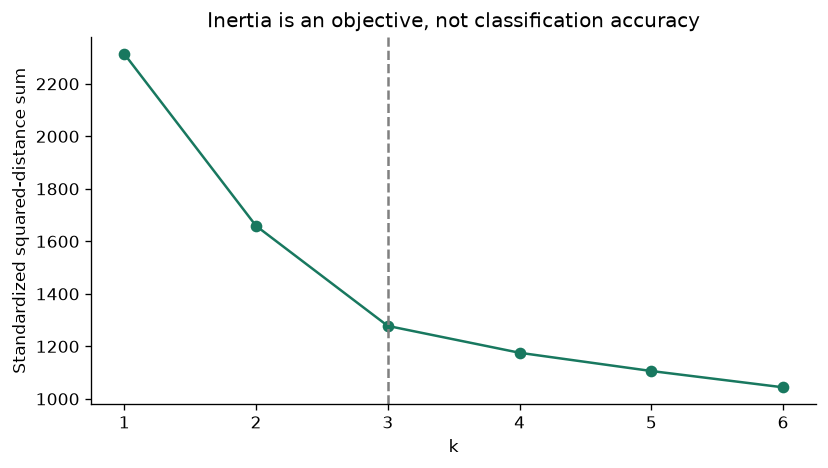

In [7]:
solutions={k:kmeans(standardized,k,seed=42,restarts=10) for k in range(1,7)}
solution=solutions[3]
fig,ax=plt.subplots(figsize=(7,4));ax.plot(list(solutions),[solutions[k]["inertia"] for k in solutions],"o-")
ax.axvline(3,color="gray",linestyle="--");ax.set(xlabel="k",ylabel="Standardized squared-distance sum",title="Inertia is an objective, not classification accuracy");plt.tight_layout();plt.show()


### 3. Project anonymous clusters

PCA only creates the display coordinates; k-means fitted all 13 standardized features. Cluster numbers and colors are arbitrary identifiers. Similar-looking clusters in two PCs may overlap in discarded directions.

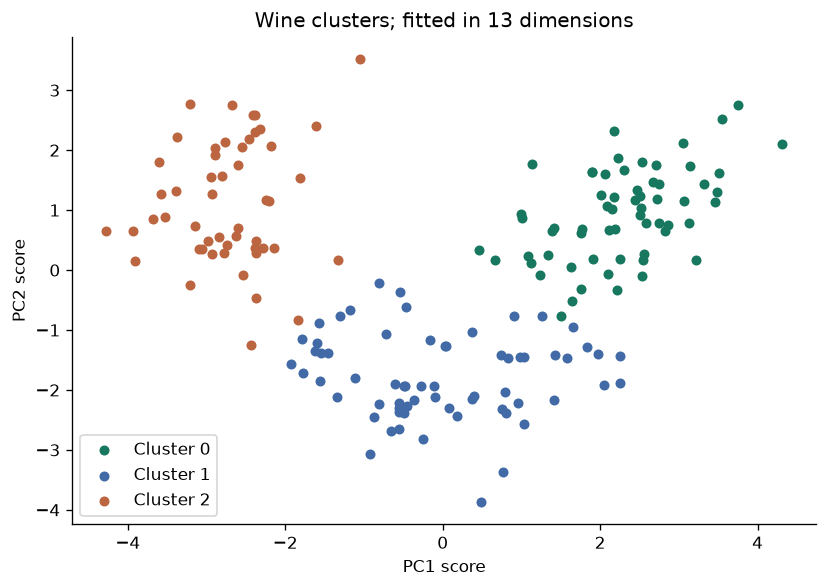

In [8]:
pca=standardized_pca(values,2)
fig,ax=plt.subplots(figsize=(7,5))
for cluster in range(3):
 mask=solution["labels"]==cluster;ax.scatter(*pca["scores"][mask].T,label=f"Cluster {cluster}",s=25)
ax.set(xlabel="PC1 score",ylabel="PC2 score",title="Wine clusters; fitted in 13 dimensions");ax.legend();plt.tight_layout();plt.show()


### 4. Compare with withheld cultivar codes

The contingency table is a descriptive comparison after fitting. Rows use source cultivar codes and columns use anonymous cluster IDs. Do not compute accuracy by directly equating these unrelated label numbers.

cluster,0,1,2
cultivar,,,
1,59,0,0
2,3,65,3
3,0,0,48


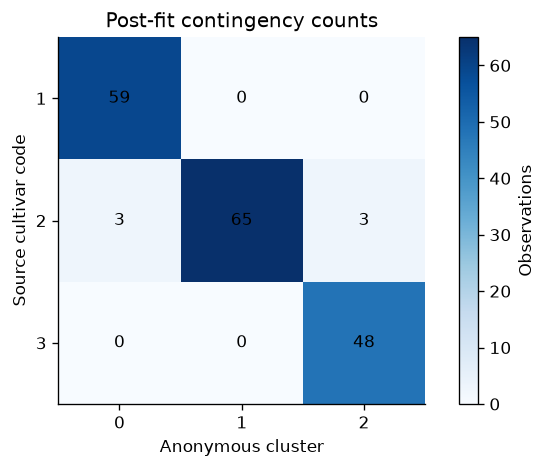

In [9]:
table=pd.crosstab(frame.cultivar,pd.Series(solution["labels"],name="cluster"))
display(table)
fig,ax=plt.subplots(figsize=(6,4));im=ax.imshow(table,cmap="Blues")
ax.set_xticks(range(3),table.columns);ax.set_yticks(range(3),table.index)
for i in range(3):
 for j in range(3):ax.text(j,i,str(table.iloc[i,j]),ha="center",va="center")
ax.set(xlabel="Anonymous cluster",ylabel="Source cultivar code",title="Post-fit contingency counts");fig.colorbar(im,ax=ax,label="Observations");plt.tight_layout();plt.show()


### 5. Check the objective and export assignments

Recompute the final objective directly from points and centres. The stored update history must not increase. Export the standardized centres with assignments and objective values; zero clusters or non-finite input should fail instead of yielding a plausible-looking plot.

In [10]:
assert table.to_numpy().sum()==178
assert np.isclose(solution["inertia"],np.sum((standardized-solution["centers"][solution["labels"]])**2))
assert np.all(np.diff(solution["history"])<=1e-8)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
frame.assign(cluster=solution["labels"]).to_csv(OUTPUT_DIR/"wine-clusters.csv",index=False)
pd.DataFrame(solution["centers"],columns=features).to_csv(OUTPUT_DIR/"standardized-centres.csv",index=False)
pd.DataFrame({"k":list(solutions),"inertia":[solutions[k]["inertia"] for k in solutions]}).to_csv(OUTPUT_DIR/"inertia.csv",index=False)
print("Objective and count checks passed; exports:",OUTPUT_DIR)


Objective and count checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ds04-wine-clusters


## Exercises and reference explanation

1. Explain why cluster IDs cannot be equated with cultivar codes.
2. Repeat ten-restart clustering with seed=7 and compare objective values.

**Reference explanation.** Cluster IDs are arbitrary and can be permuted without changing membership. Different initializations can reach different local minima; source-code comparison is descriptive and occurs after fitting.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/Pandas/Matplotlib, add a labelled standardized-centre heatmap without including cultivar codes in the distance calculation.

**Prompt 2**

> Using the same packages, compare one and ten restarts at k=3 and show both objective histories.

**Human acceptance.** Recomputed inertia must match, histories must not increase, assignment counts sum to 178 and all centres are finite.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [11]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://archive.ics.uci.edu/dataset/109',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [UCI wine](https://archive.ics.uci.edu/static/public/109/wine.zip) — CC BY 4.0; credit UCI and original dataset authors; retrieved 2026-10-09. SHA-256 `2bae62c4481220623579d4c4fb36b55652b6b75e06e49fa1981b8198362dfdab`.
  Extract wine.data from original download; preserve all rows and declared units; no imputation.
  Aeberhard, S. & Forina, M. (1992). Wine. UCI Machine Learning Repository. DOI: 10.24432/C5PC7J.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.